In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


#IMPORTS

import torch
import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000011197.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000151000.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000356531.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000125257.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000334399.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000439715.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000437351.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000366884.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000515025.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000349594.jpg
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017/000000119365.jpg
/kaggle/input/datasets/asad11914/coco-2017-

KeyboardInterrupt: 

In [ ]:


import os

for dataset in os.listdir('/kaggle/input'):
    print(f"\n{'='*50}")
    print(f"DATASET: {dataset}")
    print('='*50)
    base = os.path.join('/kaggle/input', dataset)
    for root, dirs, files in os.walk(base):
        rel = root.replace(base, '').strip('/')
        depth = rel.count('/') if rel else 0
        indent = '  ' * depth
        name = os.path.basename(root) if rel else '.'
        print(f"{indent}{name}/  ({len(files)} files)")
        # mostra i primi 3 file di ogni cartella come esempio
        for f in files[:3]:
            print(f"{indent}    {f}")
        if len(files) > 3:
            print(f"{indent}    ... e altri {len(files)-3} file")

In [7]:
# === Globals: percorsi dataset ===

COCO_ROOT = '/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017'
COCO_TRAIN_IMG = f'{COCO_ROOT}/train2017'
COCO_VAL_IMG   = f'{COCO_ROOT}/val2017'
COCO_TRAIN_ANN = f'{COCO_ROOT}/annotations/person_keypoints_train2017.json'
COCO_VAL_ANN   = f'{COCO_ROOT}/annotations/person_keypoints_val2017.json'

# Parametri della pipeline
NUM_KEYPOINTS = 17           # keypoint standard COCO
INPUT_SIZE    = (256, 192)   # (altezza, larghezza) — standard per pose estimation
HEATMAP_SIZE  = (64, 48)     # heatmap a 1/4 della risoluzione input
SIGMA         = 2            # ampiezza della gaussiana nelle heatmap

OCHUMAN_IMG = '/kaggle/input/ochuman/images/images'
OCHUMAN_VAL_ANN  = '/kaggle/input/ochuman/ochuman_coco_format_val_range_0.00_1.00.json'
OCHUMAN_TEST_ANN = '/kaggle/input/ochuman/ochuman_coco_format_test_range_0.00_1.00.json'

loading annotations into memory...
Done (t=0.40s)
creating index...
index created!


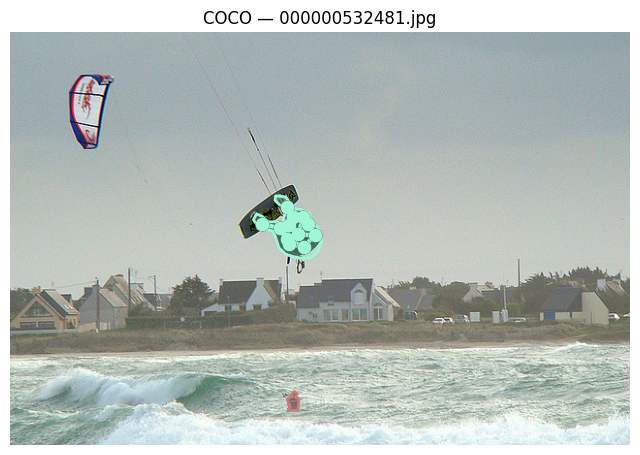

Immagine: 000000532481.jpg
Persone annotate: 2
Keypoint della prima persona: 12/17


In [4]:
import json
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Carica le annotazioni COCO val
coco = COCO(COCO_VAL_ANN)

# Prendi un'immagine che contiene persone con keypoint
person_ids = coco.getCatIds(catNms=['person'])
img_ids = coco.getImgIds(catIds=person_ids)
img_info = coco.loadImgs(img_ids[0])[0]

# Carica e mostra l'immagine con lo scheletro
img = mpimg.imread(f"{COCO_VAL_IMG}/{img_info['file_name']}")
plt.figure(figsize=(8,8))
plt.imshow(img)
ann_ids = coco.getAnnIds(imgIds=img_info['id'], catIds=person_ids)
anns = coco.loadAnns(ann_ids)
coco.showAnns(anns)
plt.title(f"COCO — {img_info['file_name']}")
plt.axis('off')
plt.show()

print(f"Immagine: {img_info['file_name']}")
print(f"Persone annotate: {len(anns)}")
print(f"Keypoint della prima persona: {anns[0]['num_keypoints']}/17")

In [5]:
import os

# Trova i path esatti delle annotazioni COCO
print("=== ANNOTAZIONI COCO ===")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'person_keypoints' in f:
            print(os.path.join(root, f))

# Trova le cartelle immagini COCO
print("\n=== CARTELLE IMMAGINI COCO ===")
for root, dirs, files in os.walk('/kaggle/input'):
    if root.endswith('train2017') or root.endswith('val2017'):
        print(f"{root} → {len(files)} file")

=== ANNOTAZIONI COCO ===
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/annotations/person_keypoints_train2017.json
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/annotations/person_keypoints_val2017.json

=== CARTELLE IMMAGINI COCO ===
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/val2017 → 2346 file
/kaggle/input/datasets/asad11914/coco-2017-keypoints/coco2017/train2017 → 56599 file


In [9]:
from pycocotools.coco import COCO

def build_samples(ann_file, min_keypoints=8, min_bbox_area=32*32):
    """
    Costruisce la lista degli esempi (una persona = un esempio).
    Filtra persone con troppo pochi keypoint o bbox troppo piccoli.
    """
    coco = COCO(ann_file)
    person_cat = coco.getCatIds(catNms=['person'])
    img_ids = coco.getImgIds(catIds=person_cat)

    samples = []
    for img_id in img_ids:
        img_info = coco.loadImgs(img_id)[0]
        ann_ids = coco.getAnnIds(imgIds=img_id, catIds=person_cat)
        anns = coco.loadAnns(ann_ids)

        for ann in anns:
            # scarta se nessun keypoint o pochi keypoint annotati
            if ann.get('num_keypoints', 0) < min_keypoints:
                continue
            # scarta bbox degeneri o troppo piccoli
            x, y, w, h = ann['bbox']
            if w * h < min_bbox_area or w <= 0 or h <= 0:
                continue

            samples.append({
                'image_id':   img_id,
                'file_name':  img_info['file_name'],
                'bbox':       ann['bbox'],              # [x, y, w, h]
                'keypoints':  ann['keypoints'],         # lista di 51 valori (17 * 3)
            })
    return samples


# Costruiamo la lista per il training (può metterci ~30-60 secondi)
train_samples = build_samples(COCO_TRAIN_ANN)
print(f"Esempi di training (persone valide): {len(train_samples)}")

# Mostriamo un esempio per capire la struttura
print("\nEsempio 0:")
for k, v in train_samples[0].items():
    if k == 'keypoints':
        print(f"  {k}: {v[:9]} ...  (primi 3 keypoint dei 17)")
    else:
        print(f"  {k}: {v}")

loading annotations into memory...
Done (t=9.18s)
creating index...
index created!
Esempi di training (persone valide): 116021

Esempio 0:
  image_id: 262145
  file_name: 000000262145.jpg
  bbox: [387, 71.1, 145, 322]
  keypoints: [407, 115, 1, 407, 105, 2, 0, 0, 0] ...  (primi 3 keypoint dei 17)


Utils

In [10]:
import numpy as np

def generate_heatmap(center_x, center_y, heatmap_h, heatmap_w, sigma):
    """
    Genera una singola heatmap (heatmap_h x heatmap_w) con una gaussiana
    centrata su (center_x, center_y).
    """
    heatmap = np.zeros((heatmap_h, heatmap_w), dtype=np.float32)

    # griglia di coordinate
    xs = np.arange(0, heatmap_w, 1, dtype=np.float32)
    ys = np.arange(0, heatmap_h, 1, dtype=np.float32)[:, np.newaxis]

    # formula della gaussiana 2D centrata su (center_x, center_y)
    heatmap = np.exp(-((xs - center_x)**2 + (ys - center_y)**2) / (2 * sigma**2))

    return heatmap


# --- Test rapido: una gaussiana al centro di una heatmap 64x48 ---
test_hm = generate_heatmap(center_x=24, center_y=32,heatmap_h=HEATMAP_SIZE[0], heatmap_w=HEATMAP_SIZE[1],sigma=SIGMA)
print(f"Shape heatmap: {test_hm.shape}")
print(f"Valore massimo (deve essere ~1.0, sul centro): {test_hm.max():.3f}")
print(f"Posizione del massimo (y, x): {np.unravel_index(test_hm.argmax(), test_hm.shape)}")

Shape heatmap: (64, 48)
Valore massimo (deve essere ~1.0, sul centro): 1.000
Posizione del massimo (y, x): (np.int64(32), np.int64(24))


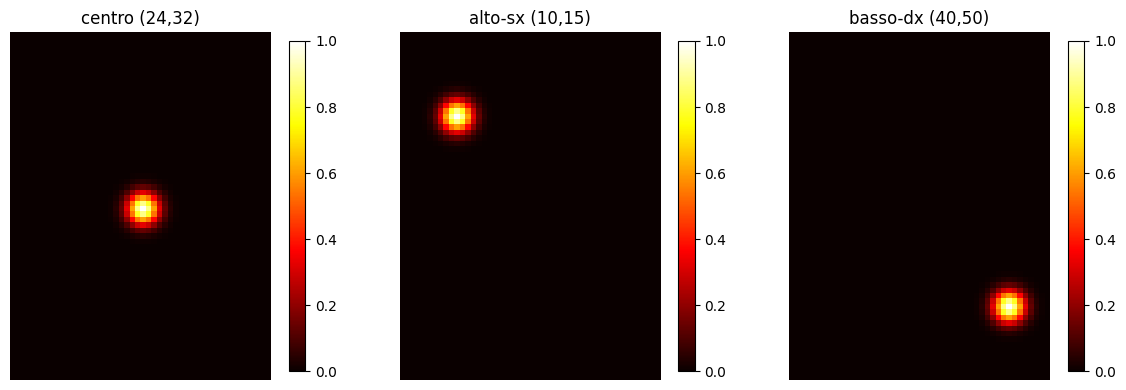

In [11]:
import matplotlib.pyplot as plt

# Generiamo 3 heatmap con gaussiane in posizioni diverse
hm1 = generate_heatmap(24, 32, *HEATMAP_SIZE, SIGMA)   # centro
hm2 = generate_heatmap(10, 15, *HEATMAP_SIZE, SIGMA)   # in alto a sinistra
hm3 = generate_heatmap(40, 50, *HEATMAP_SIZE, SIGMA)   # in basso a destra

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, hm, title in zip(axes, [hm1, hm2, hm3],['centro (24,32)', 'alto-sx (10,15)', 'basso-dx (40,50)']):
    im = ax.imshow(hm, cmap='hot')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

In [20]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os

class COCOKeypointsDataset(Dataset):
    def __init__(self, samples, img_dir, input_size, heatmap_size, sigma, num_kpts):
        self.samples = samples
        self.img_dir = img_dir
        self.input_h, self.input_w = input_size
        self.hm_h, self.hm_w = heatmap_size
        self.sigma = sigma
        self.num_kpts = num_kpts

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # carica immagine (BGR -> RGB)
        img_path = os.path.join(self.img_dir, s['file_name'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # ritaglia la persona col bounding box
        x, y, w, h = s['bbox']
        x, y, w, h = int(x), int(y), int(w), int(h)
        crop = img[y:y+h, x:x+w]

        # 1. scala uniforme (preserva aspect ratio)
        scale = min(self.input_w / w, self.input_h / h)
        new_w = int(w * scale)
        new_h = int(h * scale)

        # 2. resize uniforme
        crop_resized = cv2.resize(crop, (new_w, new_h))

        # 3. padding centrato per arrivare a input_size
        pad_top  = (self.input_h - new_h) // 2
        pad_left = (self.input_w - new_w) // 2
        canvas = np.zeros((self.input_h, self.input_w, 3), dtype=np.uint8)
        canvas[pad_top:pad_top+new_h, pad_left:pad_left+new_w] = crop_resized

        # 4. keypoint -> heatmap
        kpts = np.array(s['keypoints']).reshape(self.num_kpts, 3)  # (17, 3): x, y, v
        heatmaps = np.zeros((self.num_kpts, self.hm_h, self.hm_w), dtype=np.float32)

        # rapporto tra risoluzione heatmap e input
        hm_scale_x = self.hm_w / self.input_w
        hm_scale_y = self.hm_h / self.input_h

        for i in range(self.num_kpts):
            kx, ky, v = kpts[i]
            if v == 0:
                continue  # keypoint non annotato: heatmap vuota

            # coordinate nel canvas (input_size), poi scalate alla heatmap
            cx = ((kx - x) * scale + pad_left) * hm_scale_x
            cy = ((ky - y) * scale + pad_top)  * hm_scale_y

            # se il keypoint cade fuori dalla heatmap, salta
            if cx < 0 or cx >= self.hm_w or cy < 0 or cy >= self.hm_h:
                continue

            heatmaps[i] = generate_heatmap(cx, cy, self.hm_h, self.hm_w, self.sigma)

        # 5. converti in tensori PyTorch
        img_tensor = torch.from_numpy(canvas).permute(2, 0, 1).float() / 255.0
        hm_tensor = torch.from_numpy(heatmaps).float()

        return img_tensor, hm_tensor


# --- Istanziamo il dataset e testiamo un singolo esempio ---
train_dataset = COCOKeypointsDataset(
    samples=train_samples,
    img_dir=COCO_TRAIN_IMG,
    input_size=INPUT_SIZE,
    heatmap_size=HEATMAP_SIZE,
    sigma=SIGMA,
    num_kpts=NUM_KEYPOINTS
)

img_t, hm_t = train_dataset[0]
print(f"Immagine tensor shape: {img_t.shape}   (deve essere [3, 256, 192])")
print(f"Heatmap tensor shape:  {hm_t.shape}   (deve essere [17, 64, 48])")
print(f"Range immagine: [{img_t.min():.2f}, {img_t.max():.2f}]   (deve essere [0, 1])")
print(f"Max heatmap: {hm_t.max():.2f}   (deve essere ~1.0)")

Immagine tensor shape: torch.Size([3, 256, 192])   (deve essere [3, 256, 192])
Heatmap tensor shape:  torch.Size([17, 64, 48])   (deve essere [17, 64, 48])
Range immagine: [0.00, 1.00]   (deve essere [0, 1])
Max heatmap: 0.99   (deve essere ~1.0)


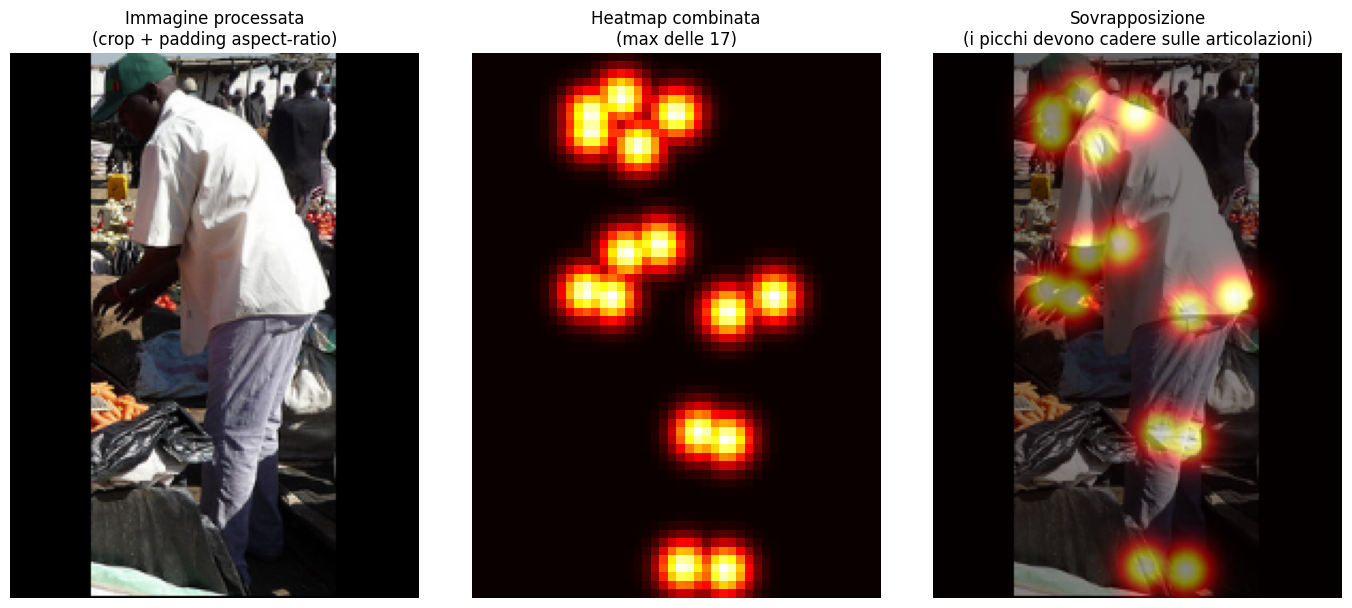

In [21]:
import matplotlib.pyplot as plt

# Prendiamo un esempio dal dataset
idx = 0
img_t, hm_t = train_dataset[idx]

# Riconvertiamo l'immagine in formato visualizzabile (H, W, 3)
img_vis = img_t.permute(1, 2, 0).numpy()

# Sommiamo tutte le 17 heatmap in una sola mappa per vedere tutti i keypoint insieme
hm_combined = hm_t.numpy().max(axis=0)   # (64, 48)

# Ridimensioniamo la heatmap combinata alla dimensione dell'immagine per sovrapporla
hm_resized = cv2.resize(hm_combined, (INPUT_SIZE[1], INPUT_SIZE[0]))

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# 1. immagine processata (crop + padding)
axes[0].imshow(img_vis)
axes[0].set_title('Immagine processata\n(crop + padding aspect-ratio)')
axes[0].axis('off')

# 2. heatmap combinata
axes[1].imshow(hm_combined, cmap='hot')
axes[1].set_title('Heatmap combinata\n(max delle 17)')
axes[1].axis('off')

# 3. sovrapposizione
axes[2].imshow(img_vis)
axes[2].imshow(hm_resized, cmap='hot', alpha=0.5)
axes[2].set_title('Sovrapposizione\n(i picchi devono cadere sulle articolazioni)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [22]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Test: prendiamo un batch e verifichiamo le dimensioni
imgs, hms = next(iter(train_loader))
print(f"Batch immagini: {imgs.shape}   (deve essere [32, 3, 256, 192])")
print(f"Batch heatmap:  {hms.shape}   (deve essere [32, 17, 64, 48])")

Batch immagini: torch.Size([32, 3, 256, 192])   (deve essere [32, 3, 256, 192])
Batch heatmap:  torch.Size([32, 17, 64, 48])   (deve essere [32, 17, 64, 48])
